In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [6]:
df = pd.read_csv("store_customers.csv")

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [10]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
F    522
M    475
Name: count, dtype: int64


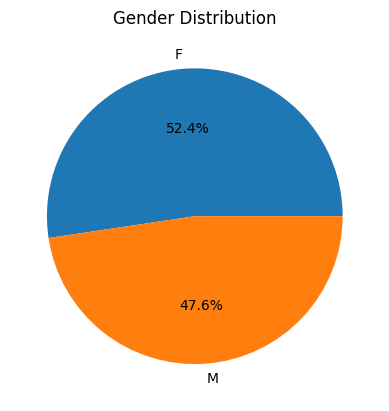

In [11]:
gender_count.plot(kind="pie", autopct="%1.1f%%")

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

In [12]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [14]:
print(df.isnull().sum())

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


In [15]:
df = df.dropna()

In [16]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

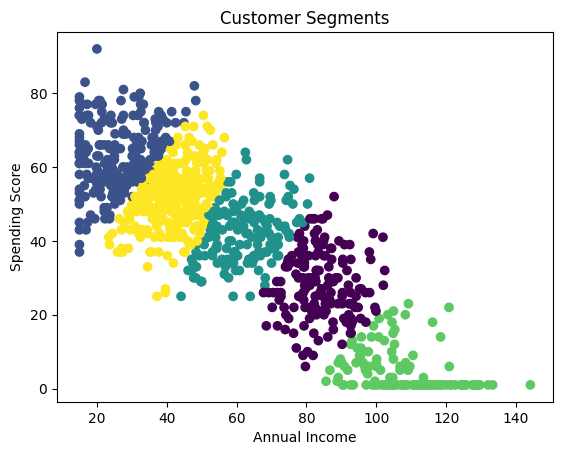

In [18]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title("Customer Segments")

plt.show()

In [19]:
cluster_analysis = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

print(cluster_analysis)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 84.168293               28.231707
1                 26.509735               62.752212
2                 61.746250               42.218750
3                108.168750                4.851562
4                 42.023355               51.476974


In [20]:
cluster_count = df["Cluster"].value_counts()

print(cluster_count)

Cluster
4    304
1    226
0    164
2    160
3    128
Name: count, dtype: int64


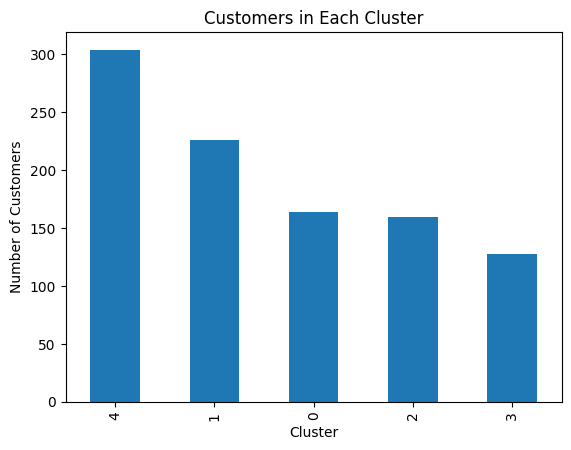

In [21]:
cluster_count.plot(kind="bar")

plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
df.to_csv("customer_segments.csv", index=False)